# Mini CSV Data Analysis
Compact analysis with extra features and clearer charts.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
sample = pd.DataFrame({
    'Age': [25, 34, 45, 52, 28, 60],
    'Gender': ['male', 'female', 'female', 'male', 'male', 'female'],
    'BMI': [22.4, 27.8, 31.2, 29.5, 24.1, 33.0],
    'Glucose': [90, 110, 145, 130, 95, 160],
    'Disease': ['healthy', 'diabetes', 'diabetes', 'hypertension', 'healthy', 'diabetes'],
    'Outcome': [0, 1, 1, 1, 0, 1]
})

raw_df = pd.read_csv('medical_data.csv') if os.path.exists('medical_data.csv') else sample
print('First 5 rows:')
display(raw_df.head())
print('Columns:', raw_df.columns.tolist())

First 5 rows:


,Age,Gender,BMI,Glucose,Disease,Outcome
0,25,male,22.4,90,healthy,0
1,34,female,27.8,110,diabetes,1
2,45,female,31.2,145,diabetes,1
3,52,male,29.5,130,hypertension,1
4,28,male,24.1,95,healthy,0


Columns: ['Age', 'Gender', 'BMI', 'Glucose', 'Disease', 'Outcome']


In [ ]:
ALIASES = {
    'age': ['age'],
    'bmi': ['bmi', 'bodymassindex'],
    'glucose': ['glucose', 'glucoselevel', 'sugar'],
    'gender': ['gender', 'sex'],
    'disease': ['disease', 'diagnosis', 'condition'],
    'outcome': ['outcome', 'target', 'result', 'label']
}

def norm(text):
    return ''.join(ch.lower() for ch in str(text) if ch.isalnum())

def find_col(df, key):
    name_map = {norm(c): c for c in df.columns}
    for candidate in ALIASES[key]:
        if candidate in name_map:
            return name_map[candidate]
    return None

df = raw_df.dropna().copy()
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.lower().str.strip()

age_col = find_col(df, 'age')
bmi_col = find_col(df, 'bmi')
glucose_col = find_col(df, 'glucose')
gender_col = find_col(df, 'gender')
disease_col = find_col(df, 'disease')
outcome_col = find_col(df, 'outcome')

for c in [age_col, bmi_col, glucose_col, outcome_col]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna()

Summary (mean, max, min):


C:\Users\josep\AppData\Local\Temp\ipykernel_17760\3670238703.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include='object').columns:


,Age,BMI,Glucose
mean,40.666667,28.0,121.666667
max,60.000000,33.0,160.000000
min,25.000000,22.4,90.000000


Disease count:


Disease
diabetes        3
healthy         2
hypertension    1
Name: count, dtype: int64

Gender count:


Gender
male      3
female    3
Name: count, dtype: int64

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
count_col = disease_col or gender_col or (cat_cols[0] if cat_cols else None)

quality = pd.DataFrame({
    'Metric': ['Rows (raw)', 'Rows (clean)', 'Columns', 'Missing values (raw)', 'Duplicate rows (raw)'],
    'Value': [len(raw_df), len(df), raw_df.shape[1], int(raw_df.isna().sum().sum()), int(raw_df.duplicated().sum())]
})
print('Data Quality:')
display(quality)

print('Summary (mean, max, min):')
if numeric_cols:
    display(df[numeric_cols].agg(['mean', 'max', 'min']).round(3))

if count_col:
    print(f'Count by {count_col}:')
    display(df[count_col].value_counts())

if disease_col and age_col and bmi_col:
    print(f'GroupBy {disease_col}: avg {age_col}, {bmi_col}')
    display(df.groupby(disease_col)[[age_col, bmi_col]].mean().round(2))
elif count_col and numeric_cols:
    print(f'GroupBy {count_col}: avg numeric columns')
    display(df.groupby(count_col)[numeric_cols].mean().round(2))

if len(cat_cols) >= 2:
    print(f'Top pairs: {cat_cols[0]} x {cat_cols[1]}')
    display(df.groupby([cat_cols[0], cat_cols[1]]).size().reset_index(name='Count').sort_values('Count', ascending=False).head(10))

if numeric_cols:
    n1 = df[numeric_cols[0]].to_numpy()
    print(f'NumPy {numeric_cols[0]} mean/sum:', np.mean(n1), np.sum(n1))
if len(numeric_cols) > 1:
    n2 = df[numeric_cols[1]].to_numpy()
    print(f'NumPy {numeric_cols[1]} mean/sum:', np.mean(n2), np.sum(n2))

if len(numeric_cols) > 1:
    print('Correlation matrix:')
    display(df[numeric_cols].corr().round(3))

GroupBy: Disease -> avg Age, BMI


,Age,BMI
Disease,,
diabetes,46.333333,30.666667
healthy,26.500000,23.250000
hypertension,52.000000,29.500000


GroupBy: Gender -> avg Glucose


Gender
female    138.333333
male      105.000000
Name: Glucose, dtype: float64

GroupBy: Outcome -> count


,Outcome,Count
0,0,2
1,1,4


NumPy mean: 40.666666666666664 28.0 121.66666666666667
NumPy sum: 244 168.0 730


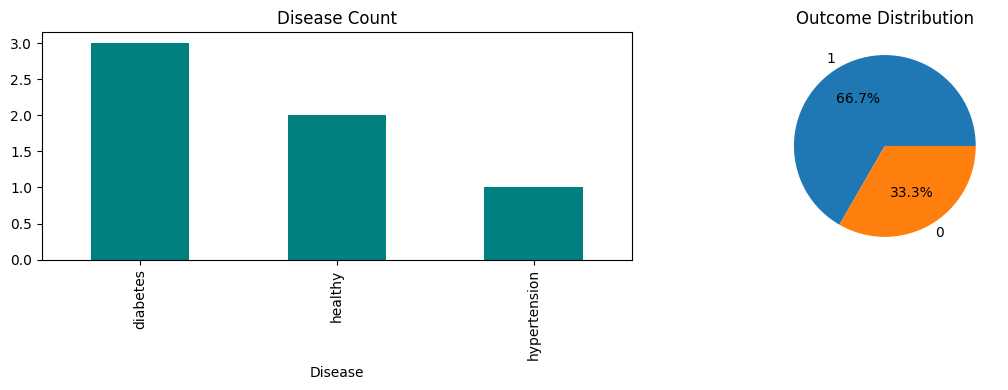

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9), dpi=120)

if count_col:
    df[count_col].value_counts().plot(kind='bar', ax=ax[0, 0], color='teal', title=f'Count by {count_col}')
    ax[0, 0].tick_params(axis='x', rotation=25)
    ax[0, 0].grid(axis='y', alpha=0.3)

pie_col = outcome_col or count_col
if pie_col:
    df[pie_col].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[0, 1], title=f'Distribution of {pie_col}')
    ax[0, 1].set_ylabel('')

if numeric_cols:
    df[numeric_cols[0]].plot(kind='hist', bins=20, color='#4C78A8', ax=ax[1, 0], title=f'Distribution of {numeric_cols[0]}')
    ax[1, 0].grid(axis='y', alpha=0.3)

if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr().values
    im = ax[1, 1].imshow(corr, cmap='coolwarm', aspect='auto')
    ax[1, 1].set_xticks(range(len(numeric_cols)))
    ax[1, 1].set_yticks(range(len(numeric_cols)))
    ax[1, 1].set_xticklabels(numeric_cols, rotation=35, ha='right')
    ax[1, 1].set_yticklabels(numeric_cols)
    ax[1, 1].set_title('Correlation Heatmap')
    fig.colorbar(im, ax=ax[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()